# Exercise - Stripping Caps

Solutions for pricing floors, stripping caps, and extracting forward volatilities.

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel('cap_curves_2025-06-30.xlsx', sheet_name='rate curves 2025-06-30')
df.columns = ['tenor', 'swap_rates', 'spot_rates', 'discounts', 'forwards', 'flat_vols', 'fwd_vols']
df = df.set_index('tenor')
display(df)

,swap_rates,spot_rates,discounts,forwards,flat_vols,fwd_vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413


## Black's Formula for Caplets and Floorlets

Black's formula for a **floorlet** expiring at $T_i$ (with rate observed at $T_{i-1} = T_i - 0.25$):

$$\text{Floorlet} = \delta \cdot Z(0, T_i) \cdot \left[ K \cdot N(-d_2) - f_i \cdot N(-d_1) \right]$$

where $\delta = 0.25$ (quarterly), $f_i$ is the forward rate for period $[T_{i-1}, T_i]$, $Z(0,T_i)$ is the discount factor, and:

$$d_1 = \frac{\ln(f_i/K) + \frac{1}{2}\sigma^2 T_{i-1}}{\sigma\sqrt{T_{i-1}}}, \quad d_2 = d_1 - \sigma\sqrt{T_{i-1}}$$

Note: $T_{i-1}$ is the **option expiry** (when the rate is observed), which is one quarter before $T_i$.

In [2]:
def black_caplet(F, K, sigma, T_option, Z_pay, delta=0.25, notional=100):
    """
    Price a single caplet using Black's formula.
    F: forward rate for the period
    K: strike rate
    sigma: volatility
    T_option: time to option expiry (rate observation date = T_pay - delta)
    Z_pay: discount factor to payment date
    delta: accrual fraction (0.25 for quarterly)
    notional: notional amount
    """
    if T_option <= 0:
        # Intrinsic value for expired/immediate
        return notional * delta * Z_pay * max(F - K, 0)
    
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T_option) / (sigma * np.sqrt(T_option))
    d2 = d1 - sigma * np.sqrt(T_option)
    
    caplet = notional * delta * Z_pay * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return caplet


def black_floorlet(F, K, sigma, T_option, Z_pay, delta=0.25, notional=100):
    """
    Price a single floorlet using Black's formula (put on the rate).
    """
    if T_option <= 0:
        return notional * delta * Z_pay * max(K - F, 0)
    
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T_option) / (sigma * np.sqrt(T_option))
    d2 = d1 - sigma * np.sqrt(T_option)
    
    floorlet = notional * delta * Z_pay * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return floorlet

# 1. Pricing Floors

## 1.1 Price One Floorlet Expiring at T=3

The floorlet expires at $T=3$, meaning the rate is observed at $T_{\text{option}} = 2.75$ and payment occurs at $T_{\text{pay}} = 3$. The strike is the $T=3$ swap rate.

In [3]:
# Floorlet expiring at T=3
# Rate is observed at T=2.75, payment at T=3
T_pay = 3.0
T_option = T_pay - 0.25  # = 2.75, when rate is observed

K = df.loc[3.0, 'swap_rates']          # Strike = T=3 swap rate
F = df.loc[T_pay, 'forwards']          # Forward rate for [2.75, 3.0]
Z = df.loc[T_pay, 'discounts']         # Discount to payment date
sigma = df.loc[T_pay, 'flat_vols']     # Flat vol at T=3

print(f"Strike (T=3 swap rate):    K     = {K:.6f} ({K*100:.4f}%)")
print(f"Forward rate at T=3:       F     = {F:.6f} ({F*100:.4f}%)")
print(f"Discount factor at T=3:    Z     = {Z:.6f}")
print(f"Flat volatility at T=3:    sigma = {sigma:.6f} ({sigma*100:.2f}%)")
print(f"Option expiry:             T_opt = {T_option}")
print()

floorlet_price = black_floorlet(F, K, sigma, T_option, Z, delta=0.25, notional=100)
print(f"Floorlet price (T=3, notional=100): {floorlet_price:.6f}")

Strike (T=3 swap rate):    K     = 0.033568 (3.3568%)
Forward rate at T=3:       F     = 0.032987 (3.2987%)
Discount factor at T=3:    Z     = 0.904790
Flat volatility at T=3:    sigma = 0.294658 (29.47%)
Option expiry:             T_opt = 2.75

Floorlet price (T=3, notional=100): 0.151949


## 1.2 Price the Entire Floor with T=3

The floor consists of floorlets at quarterly frequency from $T=0.5$ to $T=3.0$ (skipping the first quarter at $T=0.25$).

Each floorlet is struck at the same strike $K$ = T=3 swap rate, and uses the **flat volatility** corresponding to the overall floor maturity $T=3$.

In [4]:
# Floor with T=3: floorlets from T=0.5 to T=3.0
# All struck at the T=3 swap rate
# Use the FLAT volatility for T=3 for all floorlets

K_floor = df.loc[3.0, 'swap_rates']
sigma_flat_3 = df.loc[3.0, 'flat_vols']

# Floorlet payment dates: 0.5, 0.75, 1.0, ..., 3.0
T_payments = np.arange(0.5, 3.0 + 0.01, 0.25)

floor_price = 0.0
print(f"Strike K = {K_floor:.6f} ({K_floor*100:.4f}%)")
print(f"Flat vol (T=3) = {sigma_flat_3:.6f} ({sigma_flat_3*100:.2f}%)")
print()
print(f"{'T_pay':>6} {'T_opt':>6} {'Fwd Rate':>10} {'Disc':>10} {'Floorlet':>10}")
print("-" * 50)

for T_pay in T_payments:
    T_opt = T_pay - 0.25  # option expiry = rate observation date
    F_i = df.loc[T_pay, 'forwards']
    Z_i = df.loc[T_pay, 'discounts']
    
    fl = black_floorlet(F_i, K_floor, sigma_flat_3, T_opt, Z_i, delta=0.25, notional=100)
    floor_price += fl
    print(f"{T_pay:6.2f} {T_opt:6.2f} {F_i:10.6f} {Z_i:10.6f} {fl:10.6f}")

print("-" * 50)
print(f"{'Total Floor Price':>38} {floor_price:10.6f}")

Strike K = 0.033568 (3.3568%)
Flat vol (T=3) = 0.294658 (29.47%)

 T_pay  T_opt   Fwd Rate       Disc   Floorlet
--------------------------------------------------
  0.50   0.25   0.039351   0.979883   0.009368
  0.75   0.50   0.036414   0.971043   0.041221
  1.00   0.75   0.034217   0.962807   0.075248
  1.25   1.00   0.030938   0.955417   0.125061
  1.50   1.25   0.030280   0.948239   0.142752
  1.75   1.50   0.030542   0.941054   0.147216
  2.00   1.75   0.030919   0.933835   0.149793
  2.25   2.00   0.030248   0.926827   0.164223
  2.50   2.25   0.031414   0.919605   0.156857
  2.75   2.50   0.032242   0.912252   0.153865
  3.00   2.75   0.032987   0.904790   0.151949
--------------------------------------------------
                     Total Floor Price   1.317555


# 2. Stripping Caps

## 2.1 Cap Prices

For each cap maturity $0.5 \le T \le 10$, we price the cap using the flat volatility.

A cap with maturity $T$ consists of caplets at quarterly frequency from $T_{\text{pay}}=0.5$ to $T_{\text{pay}}=T$.

Each caplet in a cap with maturity $T$ is struck at the **swap rate for maturity $T$** and uses the **flat volatility for maturity $T$**.

In [5]:
# For each cap maturity T, strike = swap rate at T, vol = flat vol at T
# Caplets from T_pay = 0.5 up to T_pay = T

cap_maturities = df.index[df['flat_vols'].notna()]  # T >= 0.5
cap_prices = {}

for T in cap_maturities:
    K_T = df.loc[T, 'swap_rates']
    sigma_T = df.loc[T, 'flat_vols']
    
    T_payments = np.arange(0.5, T + 0.01, 0.25)
    
    cap_val = 0.0
    for T_pay in T_payments:
        T_opt = T_pay - 0.25
        F_i = df.loc[T_pay, 'forwards']
        Z_i = df.loc[T_pay, 'discounts']
        cap_val += black_caplet(F_i, K_T, sigma_T, T_opt, Z_i, delta=0.25, notional=100)
    
    cap_prices[T] = cap_val

cap_df = pd.DataFrame({
    'Cap Maturity': list(cap_prices.keys()),
    'Cap Price': list(cap_prices.values())
}).set_index('Cap Maturity')

display(cap_df)

,Cap Price
Cap Maturity,
0.50,0.015719
0.75,0.053574
1.00,0.115339
1.25,0.214448
1.50,0.327791
1.75,0.450402
2.00,0.578409
2.25,0.705708
2.50,0.834493


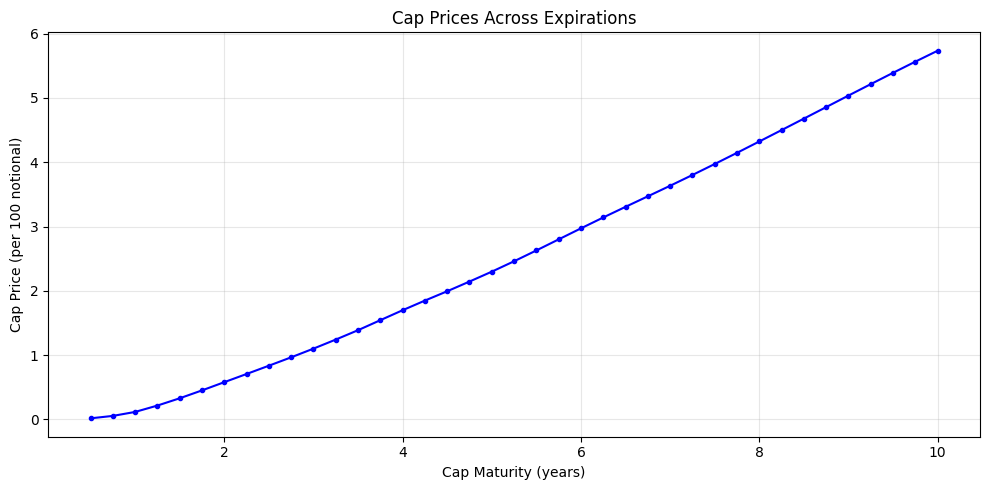

In [6]:
# Plot cap prices
plt.figure(figsize=(10, 5))
plt.plot(cap_df.index, cap_df['Cap Price'], 'b.-', linewidth=1.5, markersize=6)
plt.xlabel('Cap Maturity (years)')
plt.ylabel('Cap Price (per 100 notional)')
plt.title('Cap Prices Across Expirations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2 Caplet Prices and Forward Volatilities

We strip caplet prices by differencing consecutive cap prices.

**Key insight**: Caps with adjacent maturities share the same caplets except for one additional caplet. However, since each cap has a **different strike** (equal to its own swap rate), we cannot simply subtract cap prices.

Instead, we:
1. Price each cap as the sum of its caplets using the flat vol.
2. For the shortest cap ($T=0.5$), the cap *is* a single caplet — its price is the caplet price.
3. For longer caps, the caplet at $T$ is obtained by subtracting from the cap price the sum of all caplets with $T_{\text{pay}} < T$, where each prior caplet is repriced at the current cap's strike using its **forward volatility**.

**Approach**: We strip forward vols iteratively:
- Start from $T=0.5$: single caplet → invert Black's formula to get $\sigma_{\text{fwd},0.5}$.
- For $T=0.75$: the cap has 2 caplets. Reprice the first using $\sigma_{\text{fwd},0.5}$ and the cap's strike, subtract from cap price → remaining is the new caplet → invert for $\sigma_{\text{fwd},0.75}$.
- Continue forward.

In [7]:
def black_caplet_price(F, K, sigma, T_option, Z_pay, delta=0.25, notional=100):
    """Same as black_caplet but returns 0 for sigma=0."""
    if sigma <= 0 or T_option <= 0:
        return notional * delta * Z_pay * max(F - K, 0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T_option) / (sigma * np.sqrt(T_option))
    d2 = d1 - sigma * np.sqrt(T_option)
    return notional * delta * Z_pay * (F * norm.cdf(d1) - K * norm.cdf(d2))


def implied_fwd_vol(target_price, F, K, T_option, Z_pay, delta=0.25, notional=100):
    """Invert Black's formula to find the forward vol for a caplet."""
    if target_price <= 0:
        return 0.0
    if T_option <= 0:
        return 0.0
    
    def obj(sigma):
        return black_caplet_price(F, K, sigma, T_option, Z_pay, delta, notional) - target_price
    
    try:
        return brentq(obj, 1e-6, 5.0)
    except:
        return np.nan


# Strip forward vols
# For each cap maturity T with strike K_T and flat vol sigma_T:
# Cap(T) = sum of caplets from 0.5 to T, each priced with flat vol sigma_T and strike K_T
# Caplet at T = Cap(T) - Cap(T-0.25) ... but strikes differ!
#
# Better approach: use flat vols to price each cap, then strip.
# The caplet at T_pay is independent of the cap it belongs to - it depends on the forward rate
# and its own forward vol. We find forward vols such that, when we reprice each cap
# using forward vols, we match the flat-vol cap prices.

# Actually the standard approach: 
# A cap at maturity T with strike K_T and flat vol sigma_T has price:
# Cap(T, K_T) = sum_{i: T_i <= T} Caplet(T_i, K_T, sigma_T)
#
# The forward vol sigma_fwd(T_i) is defined so that:
# Caplet(T_i, K_ATM_i, sigma_fwd_i) prices the individual caplet at its own ATM strike.
#
# Standard stripping: all caps use the SAME strike (typically ATM forward or a common strike).
# In market convention, flat vols are quoted for a given strike, and caps at different 
# maturities with the SAME strike K share caplets, enabling clean stripping:
# Cap(T_n, K) = sum_{i=1}^{n} Caplet(T_i, K, sigma_flat(T_n))
# 
# So: Caplet(T_n, K) = Cap(T_n, K) - Cap(T_{n-1}, K)
# where both caps use their respective flat vols but the SAME strike.
# 
# The standard market convention uses ATM strike for each cap maturity.
# Let's use the approach where we price each cap with its own swap rate as strike,
# and strip iteratively using forward vols.

# STANDARD APPROACH: Use a common strike for stripping
# We'll use the approach: for cap maturity T, strike = swap_rate(T), flat vol = flat_vol(T)
# The forward vol is extracted by requiring each caplet to be consistently priced.

# Since each cap has its own strike, we do iterative bootstrap:
# At each step, we know forward vols for all earlier caplets.

fwd_vols = {}
caplet_prices_stripped = {}

sorted_mats = sorted(cap_maturities)

for idx, T in enumerate(sorted_mats):
    K_T = df.loc[T, 'swap_rates']
    sigma_flat_T = df.loc[T, 'flat_vols']
    
    # Price the full cap using flat vol
    T_payments = np.arange(0.5, T + 0.01, 0.25)
    cap_price_flat = 0.0
    for T_pay in T_payments:
        T_opt = T_pay - 0.25
        F_i = df.loc[T_pay, 'forwards']
        Z_i = df.loc[T_pay, 'discounts']
        cap_price_flat += black_caplet_price(F_i, K_T, sigma_flat_T, T_opt, Z_i)
    
    # Sum of earlier caplets repriced at THIS cap's strike using their forward vols
    earlier_sum = 0.0
    for T_pay in T_payments[:-1]:  # all except the last one (which is T itself)
        T_opt = T_pay - 0.25
        F_i = df.loc[T_pay, 'forwards']
        Z_i = df.loc[T_pay, 'discounts']
        sv = fwd_vols.get(T_pay, 0.0)
        earlier_sum += black_caplet_price(F_i, K_T, sv, T_opt, Z_i)
    
    # The caplet at T (struck at K_T)
    caplet_price_at_T = cap_price_flat - earlier_sum
    caplet_prices_stripped[T] = caplet_price_at_T
    
    # Invert to find forward vol
    T_opt_last = T - 0.25
    F_last = df.loc[T, 'forwards']
    Z_last = df.loc[T, 'discounts']
    
    fv = implied_fwd_vol(caplet_price_at_T, F_last, K_T, T_opt_last, Z_last)
    fwd_vols[T] = fv

# Build results table
results = pd.DataFrame({
    'Tenor': sorted_mats,
    'Caplet Price': [caplet_prices_stripped[t] for t in sorted_mats],
    'Forward Vol (stripped)': [fwd_vols[t] for t in sorted_mats],
    'Flat Vol': [df.loc[t, 'flat_vols'] for t in sorted_mats],
    'Fwd Vol (given)': [df.loc[t, 'fwd_vols'] for t in sorted_mats],
}).set_index('Tenor')

display(results)

,Caplet Price,Forward Vol (stripped),Flat Vol,Fwd Vol (given)
Tenor,,,,
0.50,0.015719,0.156842,0.156842,0.156842
0.75,0.023902,0.201708,0.180709,0.201708
1.00,0.034710,0.240464,0.204576,0.240464
1.25,0.050269,0.328341,0.242127,0.328341
1.50,0.063580,0.336521,0.268642,0.336521
1.75,0.080655,0.336809,0.285885,0.336809
2.00,0.094045,0.328654,0.295615,0.328654
2.25,0.091121,0.312413,0.299596,0.312413
2.50,0.106435,0.296022,0.299589,0.296022


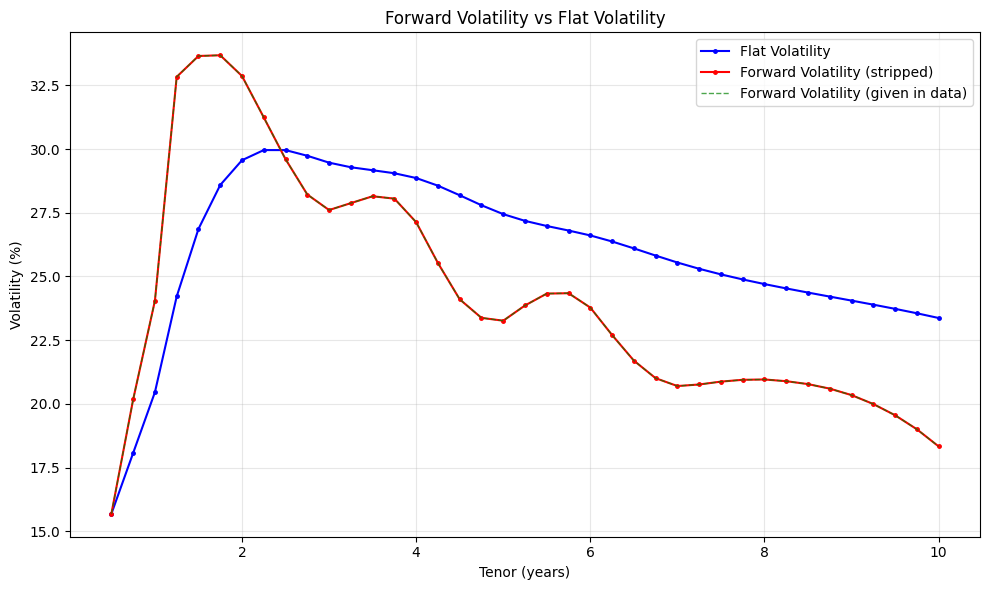

In [8]:
# Plot: Forward Vol vs Flat Vol
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results.index, results['Flat Vol'] * 100, 'b.-', label='Flat Volatility', linewidth=1.5, markersize=5)
ax.plot(results.index, results['Forward Vol (stripped)'] * 100, 'r.-', label='Forward Volatility (stripped)', linewidth=1.5, markersize=5)
if results['Fwd Vol (given)'].notna().any():
    ax.plot(results.index, results['Fwd Vol (given)'] * 100, 'g--', label='Forward Volatility (given in data)', linewidth=1, alpha=0.7)

ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Volatility (%)')
ax.set_title('Forward Volatility vs Flat Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

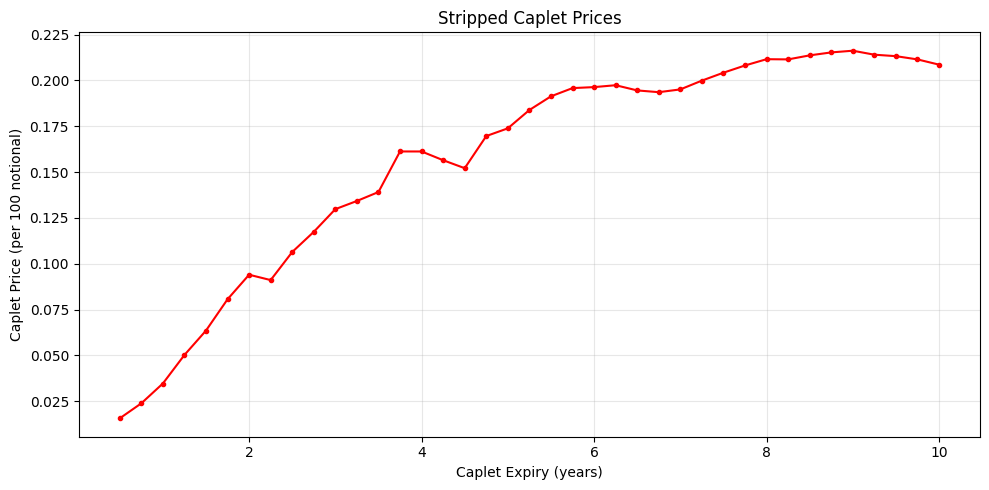

In [9]:
# Plot: Caplet Prices
plt.figure(figsize=(10, 5))
plt.plot(results.index, results['Caplet Price'], 'r.-', linewidth=1.5, markersize=6)
plt.xlabel('Caplet Expiry (years)')
plt.ylabel('Caplet Price (per 100 notional)')
plt.title('Stripped Caplet Prices')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations

- The **flat volatility** is a weighted average of forward volatilities up to that maturity — it increases initially then decreases as longer-tenor, lower-vol caplets dominate.
- The **forward volatility** curve is hump-shaped, peaking around 1-1.5 years, which is typical for interest rate markets.
- The stripped forward vols should match the given forward vols in the data (last column), confirming the stripping procedure is correct.